# PUC-Rio 
## Departamento de Engenharia Elétrica
## Trabalho 3 - Mapas de Kohonen

Estudante:

In [1]:
!git clone https://github.com/mdrs-thiago/minisom
import os 
os.chdir('minisom')

Cloning into 'minisom'...
remote: Enumerating objects: 1789, done.
remote: Counting objects: 100% (539/539), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 1789 (delta 498), reused 464 (delta 464), pack-reused 1250 (from 2)
Receiving objects: 100% (1789/1789), 15.66 MiB | 6.00 MiB/s, done.
Resolving deltas: 100% (995/995), done.


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.preprocessing import minmax_scale, StandardScaler

from minisom import MiniSom

In [3]:
dataset = pd.read_csv('https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/c_thyroid.csv')

In [4]:
values = dataset.values[:,:-1]

## Parte 1 - Testando configurações

Nesta primeira etapa, iremos investigar como a configuração do mapa pode mudar de acordo com a escolha de parâmetros. 

In [5]:
print(values.shape)

(215, 5)


##### 1. Escolha os parâmetros para o primeiro teste usando SOM. Para cada parâmetro, justifique sua escolha. Avalie o resultado.

In [42]:
#decay function 


def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 50 * m * n #! Número menor para a fase de ordenaçao.
finetuning_time = 500 * m * n #! formula nos Slides
decay_fun =  decay_fcn 


#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)





Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios


In [43]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)


 [ 3200 / 3200 ] 100% - 0:00:00 left 
 quantization error: 0.07852919791545691


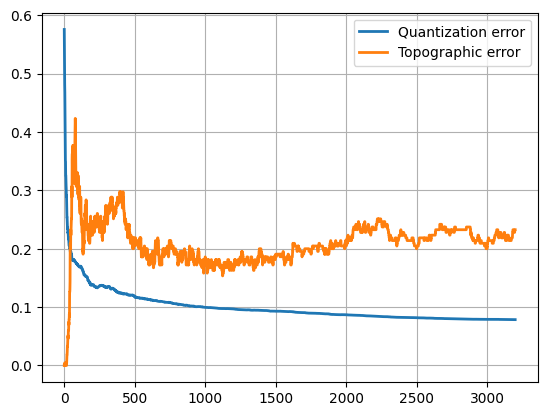

In [44]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

In [45]:
som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)


 [ 32000 / 32000 ] 100% - 0:00:00 left 
 quantization error: 0.08401006290248024


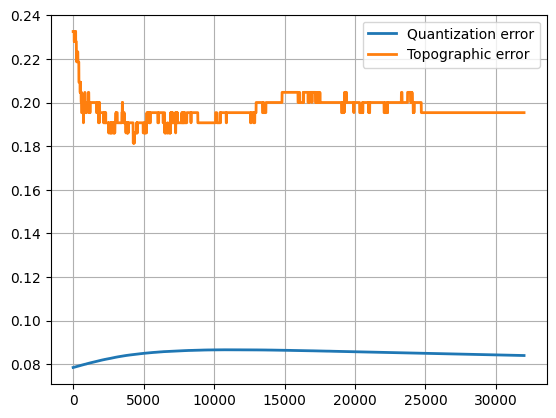

In [47]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

Após uma revisão na internet, encontrei uma relação razoável para o número de neurônios. Escolhi então usar essa relação para selecionar o número de neurônio que se daria por 5*sqrt(N), sendo N o número de amostras. Como se trata de uma rede, considerei o mesmo número de neurônios pela largura e altura tomando m=n=sqrt(5*sqrt(N))

Os parâmetros taxa de aprendizagem e número de iterações foram modificados. Na fase de ordenação, devemos ter uma taxa de aprendizagem alta e poucas iterações, fazendo com que mude rapidamente os pesos no treinamento. Sendo assim foram escolhidos 0.1 para a taxa de aprendizagem e 50*m*n para o número de iterações. Esses valores foram escolhidos de tal maneira que a taxa da fase de ajuste fino deva ser > 0.02 e, portanto, foi escolhido um valor de 0.001. O número de iterações foi escolhido de maneira que seja menor que 500 vezes o número de neurônios.

Na fase de ordenação buscamos exatamente o contrário, uma mudança devagar nos pesos ao longo de muitas iterações. Sendo assim foi escolhido um valor pequena para a taxa de aprendizagem de 0.001 < 0.02 e um número de iterações de 500 vezes o número de neurônios.

Ademais, é possível, analisar que o erro de quantização (QE) cai exponencialmente, como esperado, mas o erro topográfico (TE) cresce primeiro e depois decresce e se estabiliza. Isso ocorre pois o raio de vizinhança é grande nas primeiras iterações, não condizendo com a distribuição dos dados, aumentando o erro. Conforme passam as iterações, o raio cai e a vizinhança começa a se aproximar da distribuição original dos dados, explicando assim pq ele cai um pouco e depois se estabiliza.


##### 2. Modifique a topologia da rede. Teste diferentes valores e avalie o resultado.

In [ ]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = int(np.sqrt(5*np.sqrt(values.shape[0]))) #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "rectangular" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

ordering_time = 50 * m * n #! Número menor para a fase de ordenaçao.
finetuning_time = 500 * m * n #! formula nos Slides
decay_fun =  decay_fcn 


#Dimensão do vetor de entrada
input_len = values.shape[1]

X = minmax_scale(values)





Dimensões do mapa de Kohonen:  8 x 8 :  64 neurônios


In [58]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

 [ 3200 / 3200 ] 100% - 0:00:00 left 
 quantization error: 0.438421409881507


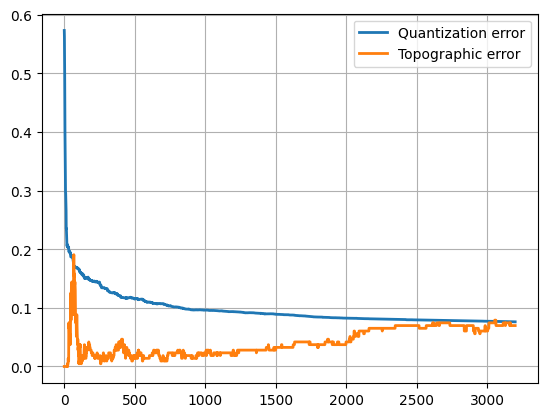

In [50]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

In [51]:
som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

 [ 32000 / 32000 ] 100% - 0:00:00 left 
 quantization error: 0.08131763160733232


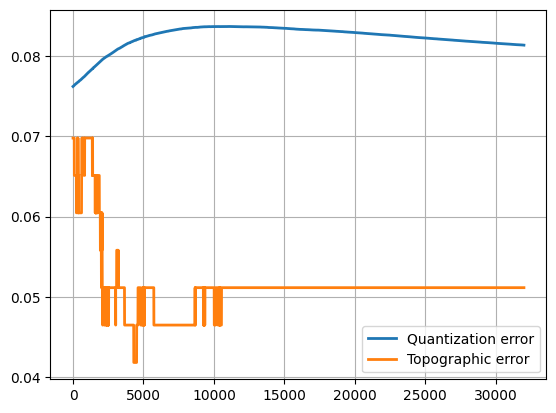

In [52]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

##### 3. Modifique a normalização dos dados de entrada e avalie o resultado obtido. Esta mudança tem algum efeito no mapa gerado?

In [81]:
#decay function 

def decay_fcn(lr,actual_t,max_t):
    '''
    Função para decaimento da taxa de aprendizado. 
    
    ## INPUTS:
    lr - Taxa de aprendizado inicial
    actual_t - Tempo atual da iteração
    max_t - Tempo máximo da iteração

    ## OUTPUT:
    - taxa de aprendizado atualizada.
    '''

    new_lr = lr/(1 + 2*actual_t/max_t)

    return new_lr


m = 10 #Dimensão X do mapa de Kohonen
n = m #Dimensão Y do mapa de Kohonen
print("Dimensões do mapa de Kohonen: ", m, "x", n, ": ", m*n, "neurônios")
lr_ordering = 0.1 #Taxa de aprendizado - Ordering phase #! Alto > 0.02
lr_finetuning = 0.001 #Taxa de aprendizado - Finetuning phase #! Slide < 0.02

topology = "hexagonal" #! A hexagonal é melhor pois permite um número maior de vizinhos, tornando mais uniforme o aprendizado.

# ordering_time = 50 * m * n #! Número menor para a fase de ordenaçao.
# finetuning_time = 500 * m * n #! formula nos Slides
ordering_time = 1000 #! Número menor para a fase de ordenaçao.
finetuning_time = 50000 #! formula nos Slides
decay_fun =  decay_fcn 


#Dimensão do vetor de entrada
input_len = values.shape[1]

# X = minmax_scale(values)
std_scaler = StandardScaler()
X = std_scaler.fit_transform(values)
print(X.shape)



Dimensões do mapa de Kohonen:  10 x 10 :  100 neurônios
(215, 5)


In [82]:
som = MiniSom(m,n,input_len,learning_rate=lr_ordering,topology=topology,decay_function=decay_fcn)
som.pca_weights_init(values)

som.train_random(X, ordering_time, verbose=True)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.5834691939271337


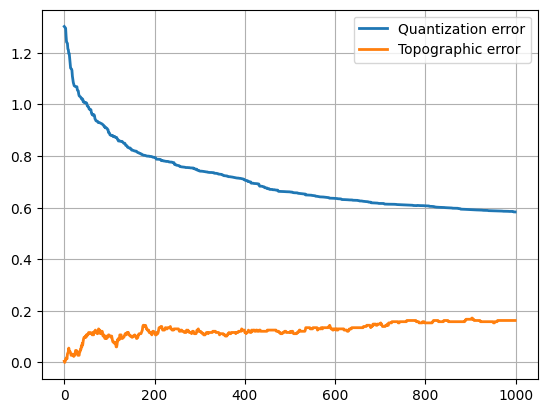

In [83]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

In [84]:
som._learning_rate = lr_finetuning #Para mudar a taxa de aprendizado durante o período de finetuning 

som.train_random(X, finetuning_time, verbose=True)

 [ 50000 / 50000 ] 100% - 0:00:00 left 
 quantization error: 0.5487229084428058


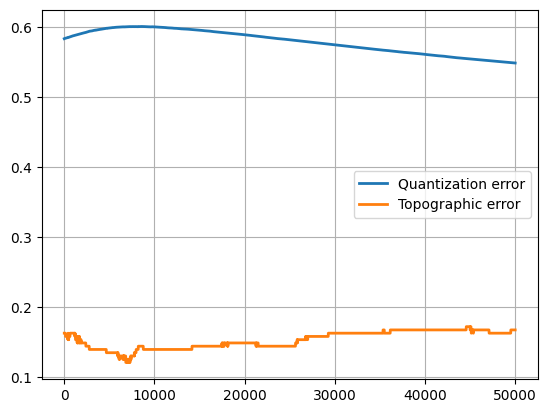

In [85]:
plt.plot(som._quantization_error,linewidth=2,label='Quantization error')
plt.plot(som._topographic_error,linewidth=2, label='Topographic error')
plt.legend()
plt.grid()

0.28867513459481287
0.28867513459481287
0.28867513459481287
0.28867513459481287
0.28867513459481287


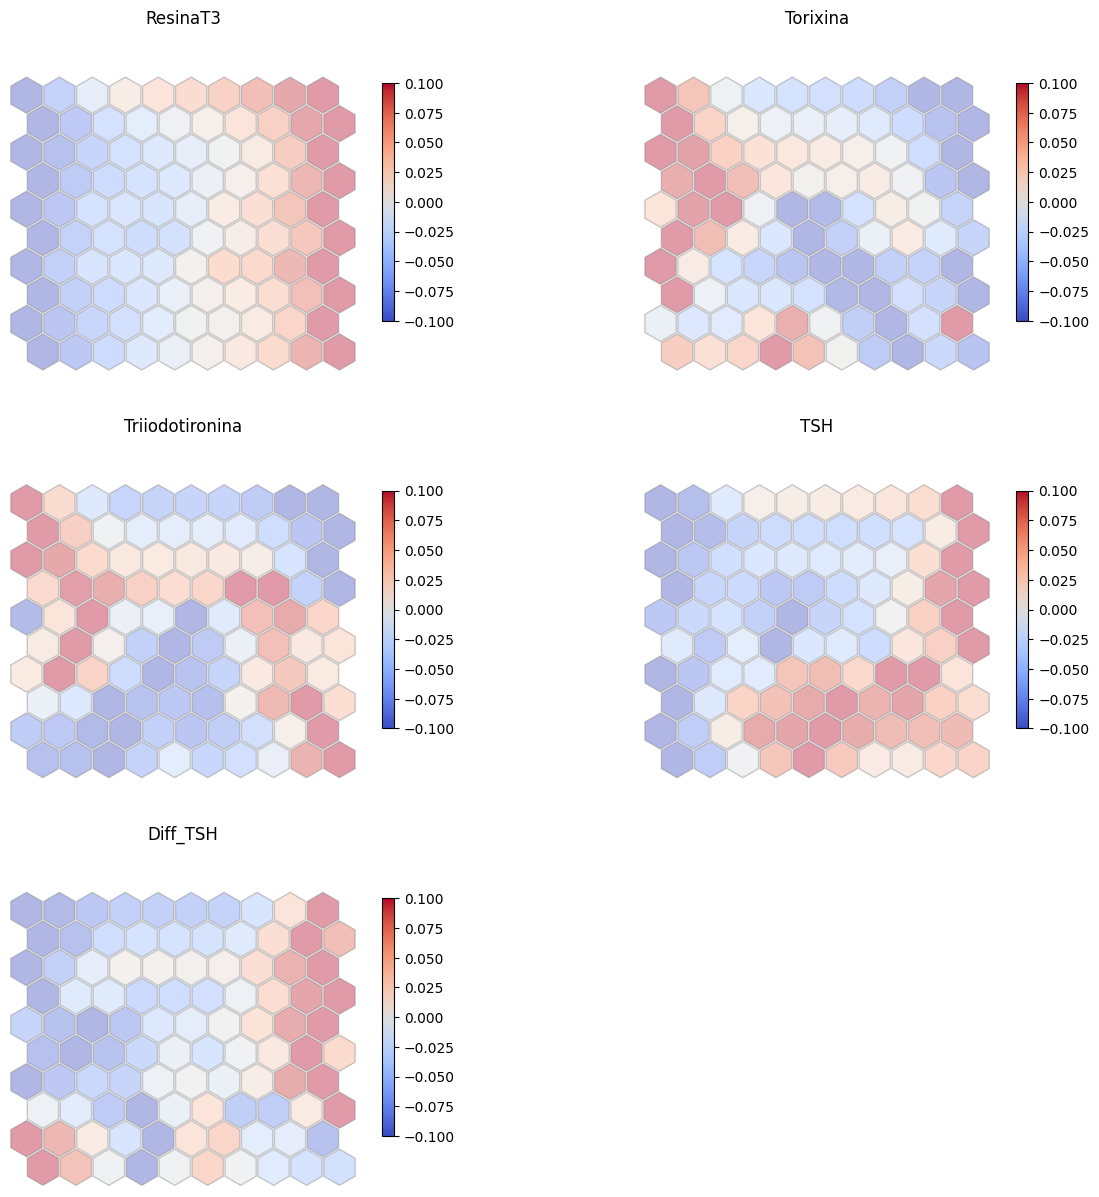

In [87]:
som.plot_map(nrows=3,ncols=2,feature_names=dataset.columns[:-1])

0.28867513459481287


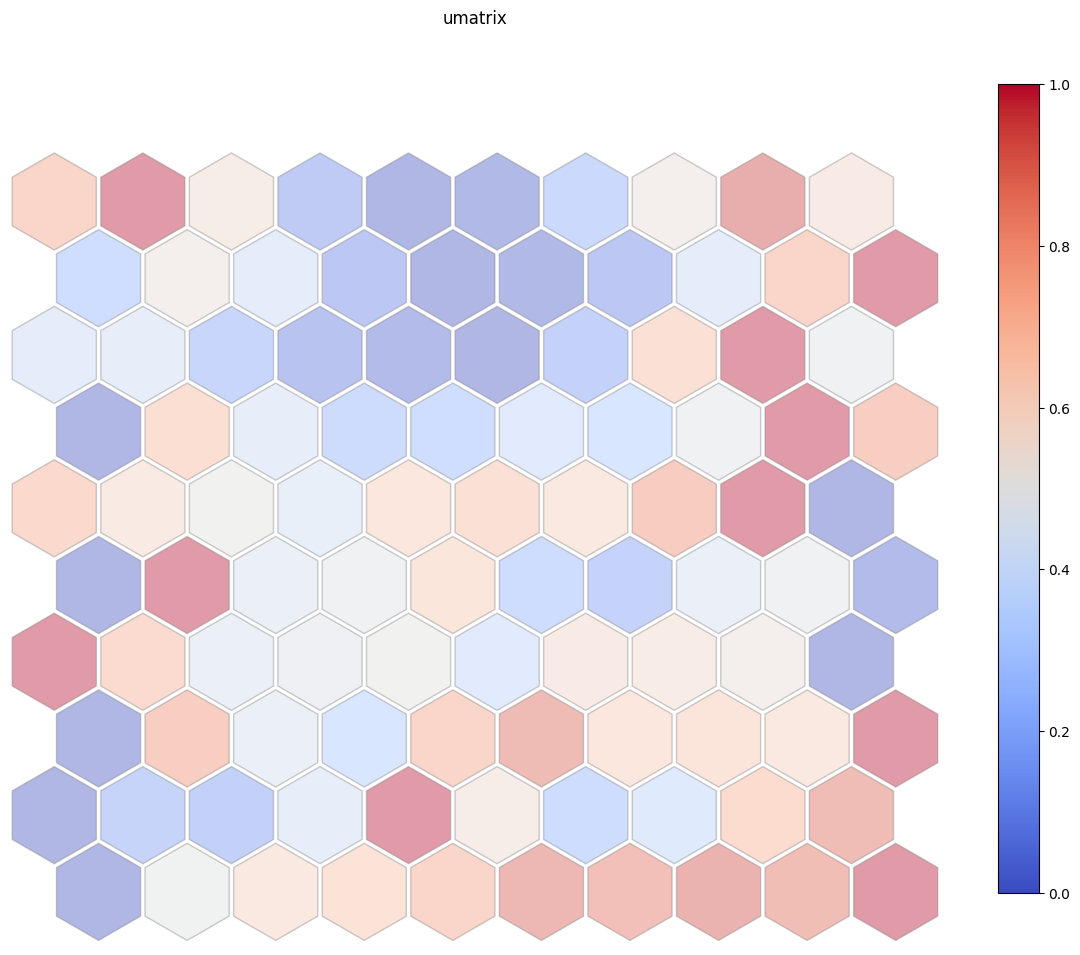

In [88]:
som.plot_umatrix()

##### 4. Modifique o processo de treinamento durante a fase de ordenação. Avalie o resultado gerado.

# Como ???

##### 5. Modifique o processo de treinamento durante a fase de ajuste fino. Avalie o resultado gerado.

# Como ??

##### 6. Modifique a função de decaimento da taxa de aprendizado. Esta mudança gera algum impacto no mapa gerado? Justifique

##### 7. Altere a função de vizinhança. Avalie o resultado.

# Para que outra função ???

## Parte 2 - Análise dos mapas

##### 1. Teste novas configurações para o modelo SOM para obter um melhor resultado. Justifique a escolha dos parâmetros do modelo selecionado.

# Igual a questão 1.1 e 1.2?

##### 2. Utilizando a melhor configuração do item anterior, analise os diferentes mapas fornecidos e caracterize os grupos de pacientes obtidos.